In [ ]:
import torch
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")
import glob
from collections import OrderedDict
from ReportPretraining import ReportClassification
from src.layers.transformer.ATAT import LightCurveTransformer, TabularTransformer


from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np


import numpy as np
from sklearn.metrics import classification_report

from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import LightCurveTransformer
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes

In [29]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 ='/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF/LC/class_all_v4_band_permute_time_normalization_0/'
PATH_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF/LC/class_all_v4_0/'

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

True False False
Using checkpoint 1776.ckpt
Using checkpoint 1776.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:04<00:00, 102.43it/s]


                precision    recall  f1-score   support

           AGN     0.3639    0.4640    0.4079       556
           QSO     0.5513    0.7263    0.6268       570
            EA     0.8600    0.6140    0.7165       570
           YSO     0.4819    0.5195    0.5000       487
          SNIa     0.5896    0.1629    0.2553       485
       CV/Nova     0.4347    0.5719    0.4939       320
          RRLc     0.6183    0.7370    0.6725       578
         RSCVn     0.3266    0.5856    0.4194       444
        Blazar     0.3273    0.3370    0.3321       270
          SNII     0.4308    0.1022    0.1652       274
         EB/EW     0.7011    0.3287    0.4476       578
           LPV     0.8468    0.7241    0.7807       580
           CEP     0.6667    0.5548    0.6056       566
         RRLab     0.6867    0.5687    0.6222       582
Periodic-Other     0.1900    0.3792    0.2531       240
          DSCT     0.3262    0.4539    0.3796       304
         SNIbc     0.3158    0.0698    0.1143  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.3638'}, xlabel='Predicted label', ylabel='True label'>

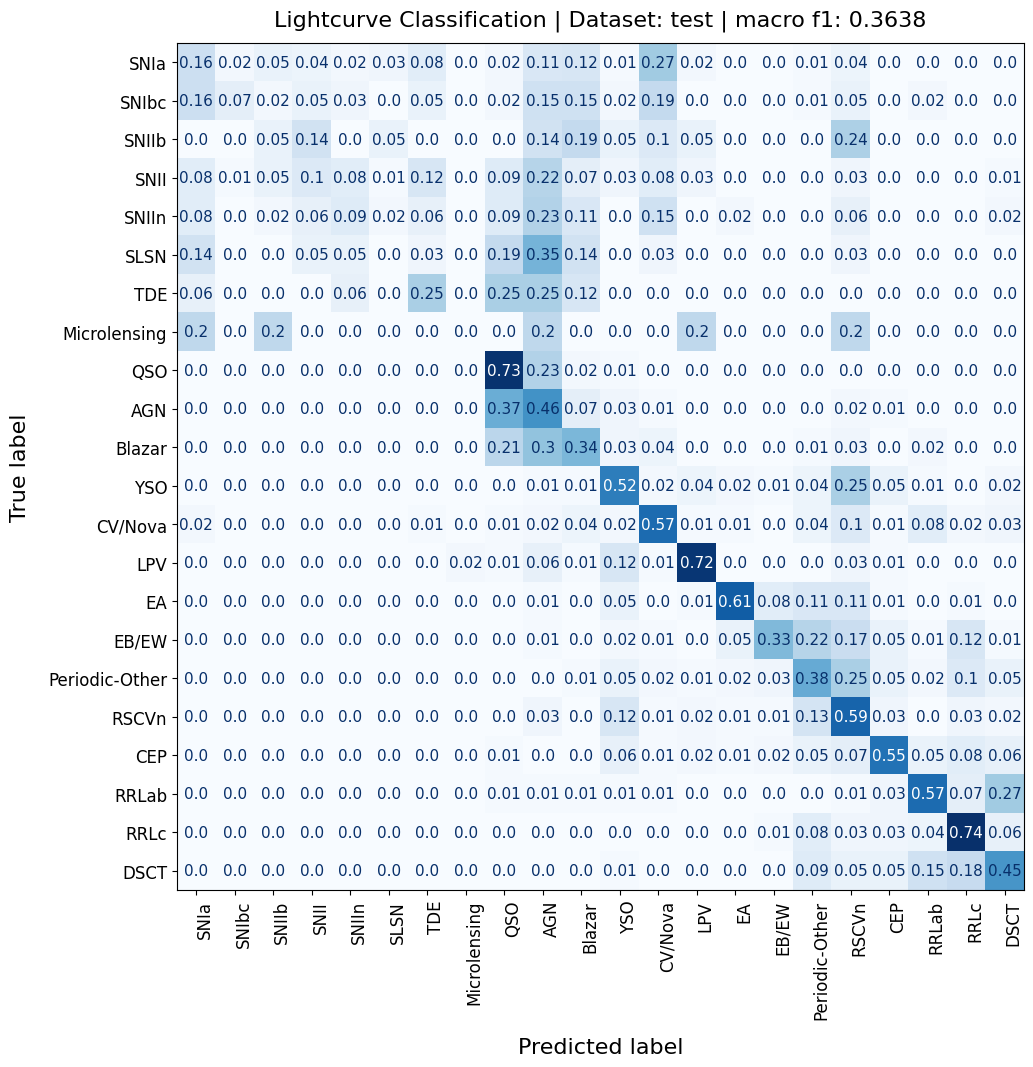

In [30]:
test = InitClassifier(path_to_config_yaml=PATH_1,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=ztf_order_classes)


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

True False False
Using checkpoint 1536.ckpt
Using checkpoint 1536.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 477/477 [00:05<00:00, 91.89it/s] 


                precision    recall  f1-score   support

           AGN     0.5564    0.3903    0.4588       556
           QSO     0.6107    0.7842    0.6866       570
            EA     0.8387    0.7754    0.8058       570
           YSO     0.5786    0.5667    0.5726       487
          SNIa     0.6946    0.7691    0.7299       485
       CV/Nova     0.7329    0.6687    0.6993       320
          RRLc     0.6779    0.7318    0.7038       578
         RSCVn     0.4669    0.5248    0.4942       444
        Blazar     0.4983    0.5481    0.5220       270
          SNII     0.7067    0.5365    0.6100       274
         EB/EW     0.6319    0.7543    0.6877       578
           LPV     0.8419    0.9276    0.8827       580
           CEP     0.7696    0.5371    0.6327       566
         RRLab     0.7304    0.7354    0.7329       582
Periodic-Other     0.4078    0.3042    0.3484       240
          DSCT     0.4148    0.4803    0.4451       304
         SNIbc     0.3117    0.2791    0.2945  

<Axes: title={'center': 'Finetuned Lightcurve Classification | Dataset: test | macro f1: 0.5075'}, xlabel='Predicted label', ylabel='True label'>

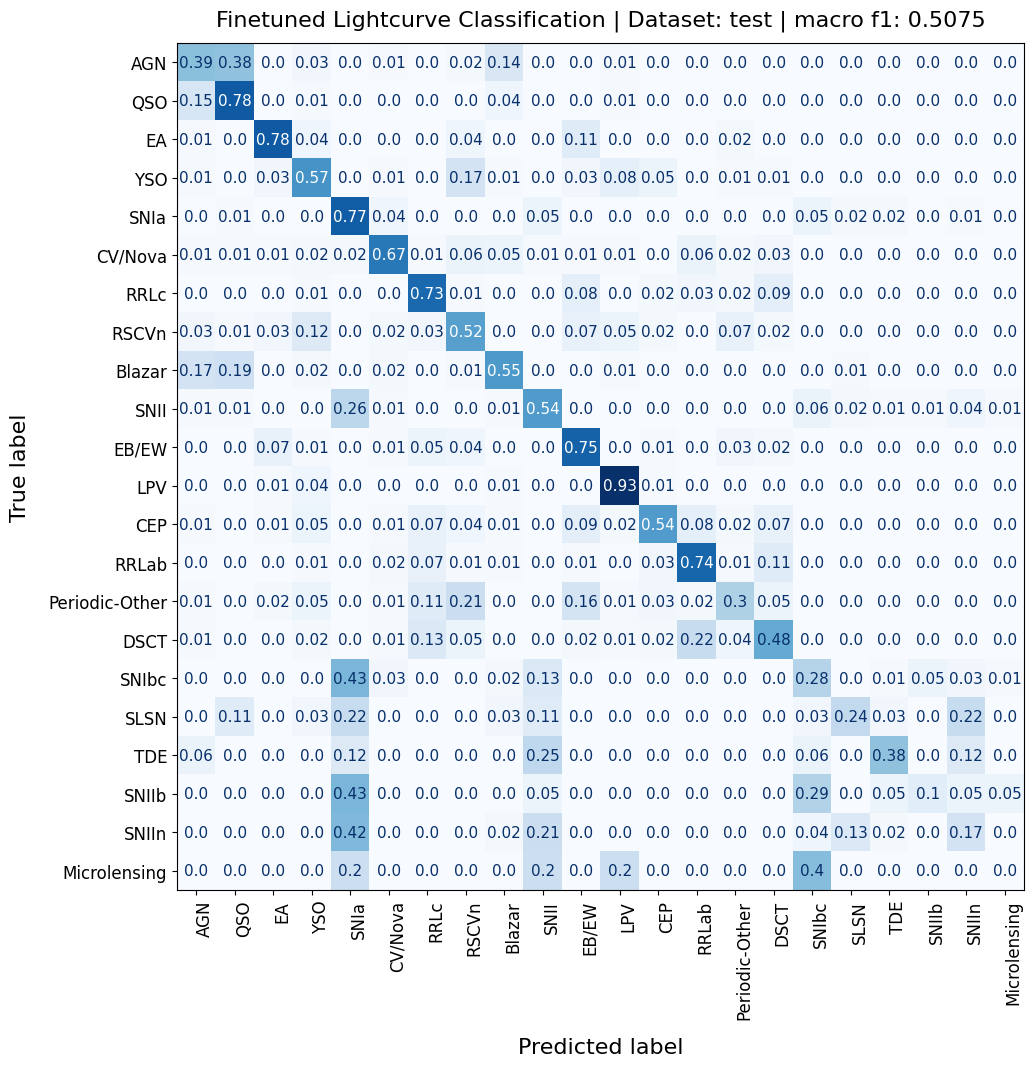

In [25]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


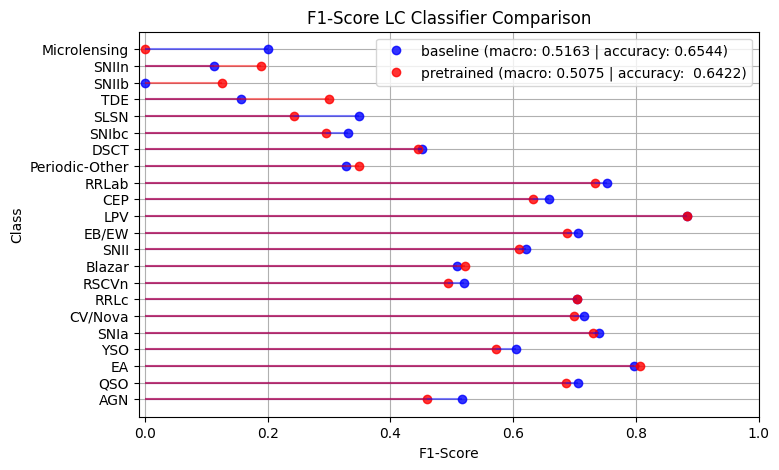

baseline f1 mean:
trans 0.31389193865829074
stoch 0.6100785685496951
per 0.6440863146949656
pretrained f1 mean:
trans 0.3127019226335407
stoch 0.598980894029588
per 0.6405619427876266


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():

            f1_baseline.append(value['f1-score'])

    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [ ]:
t_ = 1import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

In [ ]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict_by_time(dl.test_dataset, DEVICE,eval_times = [t_]) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)


True False False
Using checkpoint 4848.ckpt
Using checkpoint 4848.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]


In [23]:
import torch

# Example tensor
bsz, seqlen, channels = 2, 5, 3
x = torch.randn(bsz, seqlen, channels)

dt = 0.2

# find min per sample (over seqlen & channels)
min_vals, _ = x.view(bsz, -1).min(dim=1)   # shape [bsz]

# reshape for broadcasting: [bsz, 1, 1]
min_vals = min_vals.view(bsz, 1, 1)

# compute mask
mask = x < (min_vals + dt)

print("x shape:", x)
print("mask shape:", mask)


x shape: tensor([[[ 3.0852e-01, -4.1230e-01, -3.1842e-01],
         [ 8.0920e-04,  4.6384e-02, -5.4418e-01],
         [-7.0441e-01, -7.7820e-01, -9.5111e-01],
         [-5.2094e-01,  7.6540e-02,  1.5215e-01],
         [ 2.2895e+00,  1.1036e+00,  1.2113e+00]],

        [[-4.2369e-02, -7.3361e-02,  6.4931e-01],
         [-3.5681e-01, -2.1312e+00, -2.7035e+00],
         [ 1.0417e-01, -1.2709e+00, -1.2558e+00],
         [-6.2700e-01, -2.2226e+00, -9.7979e-01],
         [ 4.0984e-01, -1.1913e+00, -2.1165e-01]]])
mask shape: tensor([[[False, False, False],
         [False, False, False],
         [False,  True,  True],
         [False, False, False],
         [False, False, False]],

        [[False, False, False],
         [False, False,  True],
         [False, False, False],
         [False, False, False],
         [False, False, False]]])


In [24]:
report_2 = classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds[t_], axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


ValueError: attempt to get argmax of an empty sequence